prior_weights: [0.28571429 0.35294118 0.36134454]
prior_mus: [76 30 69]
prior_sigmas: [ 1 20 27]


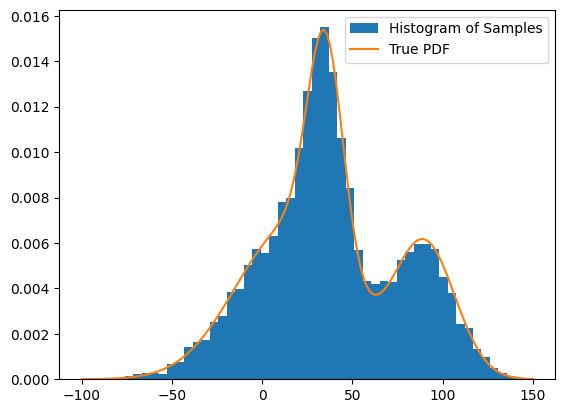

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import Generator, PCG64
from scipy.stats import norm
rng = Generator(PCG64())

def gaussian_mixture_pdf(samples, weights, mus, sigmas):
  """
  Calculates the probability density function (PDF) of a Gaussian Mixture Model.

  Args:
      samples (np.ndarray): An array of samples.
      weights (np.ndarray): Array of weights for each Gaussian component. Must sum to 1.
      mus (np.ndarray): Array of means for each Gaussian component.
      sigmas (np.ndarray): Array of standard deviations for each Gaussian component.
  Returns:
      np.ndarray
  """
  samples = np.array([weights[i] * norm(loc=mus[i], scale=sigmas[i]).pdf(samples) for i in range(len(weights))])
  return np.sum(samples, axis=0)



def gaussian_mixture_samples(weights, mus, sigmas, N_samples):
  """
  Generates samples from a Gaussian Mixture Model.

  Args:
      weights (np.ndarray): Array of weights for each Gaussian component. Must sum to 1.
      mus (np.ndarray): Array of means for each Gaussian component.
      sigmas (np.ndarray): Array of standard deviations for each Gaussian component.
      N_samples (int): The total number of samples to generate.

  Returns:
      np.ndarray: An array of generated samples from the mixture model.
  """
  # Choose which Gaussian component to sample from for each sample based on weights
  component_indices = np.random.choice(len(weights), size=N_samples, p=weights)

  # Select the corresponding means and standard deviations for each chosen component
  chosen_mus = mus[component_indices]
  chosen_sigmas = sigmas[component_indices]

  # Generate samples from the normal distribution using the chosen parameters
  samples = np.random.normal(loc=chosen_mus, scale=chosen_sigmas)
  return samples


def rejection_sampling(x, true_weights, true_mus, true_sigmas, num_samples):
    """
    Performs rejection sampling to generate samples from a target Gaussian Mixture Model.
    
    Args:
        samples (np.ndarray): An array of samples to evaluate.
        true_weights (np.ndarray): Array of weights for the target Gaussian components.
        true_mus (np.ndarray): Array of means for the target Gaussian components.
        true_sigmas (np.ndarray): Array of standard deviations for the target Gaussian components.
    """
    mixture_pdf = gaussian_mixture_pdf(x, true_weights, true_mus, true_sigmas)
    norm_pdf = norm.pdf(x, loc=40, scale=50)
    k = 0
    samples = []
    pdfs = []
    for (mixture_pdf_val, norm_pdf_val) in zip(mixture_pdf, norm_pdf):
        if mixture_pdf_val > norm_pdf_val:
            k = max(k, mixture_pdf_val / norm_pdf_val)
    while len(samples) < num_samples:
        z_0 = norm.rvs(loc=40, scale=50)
        target_pdf_val = gaussian_mixture_pdf(np.array([z_0]), true_weights, true_mus, true_sigmas)[0]
        proposal_pdf_val = norm.pdf(z_0, loc=40, scale=50)
        u = np.random.uniform(0, k*proposal_pdf_val)
        if u < target_pdf_val:
            samples.append(z_0)
            pdfs.append(u)
    return np.array(samples), np.array(pdfs)





true_weights = np.array([0.5, 0.25, 0.25])
true_mus = np.array([15, 35, 90])
true_sigmas = np.array([30, 10, 17])
N_samples = 10000

prior_weights = np.random.randint(low=1, high=100, size=3)
prior_weights = prior_weights / np.sum(prior_weights)
prior_mus = np.random.randint(low=1, high=100, size=3)
prior_sigmas = np.random.randint(low=1, high=100, size=3)

print("prior_weights:", prior_weights)
print("prior_mus:", prior_mus)
print("prior_sigmas:", prior_sigmas)


# Generate samples using the kernel variablesA
true_generated_samples = gaussian_mixture_samples(true_weights, true_mus, true_sigmas, N_samples)
plt.hist(true_generated_samples, bins=50, density=True, label="Histogram of Samples")
x = np.linspace(-100, 150, 150)
pdf = gaussian_mixture_pdf(x, true_weights, true_mus, true_sigmas)
plt.plot(x, pdf, label="True PDF")
plt.legend()
plt.show()

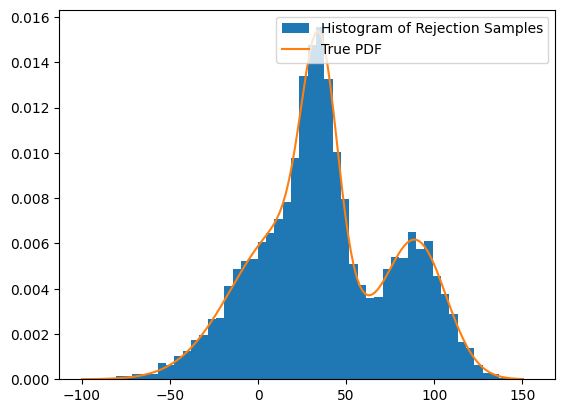

In [12]:
N_samples = 10000
samples,pdfs = rejection_sampling(x, true_weights, true_mus, true_sigmas, N_samples)
plt.hist(samples, bins=50, density=True, label="Histogram of Rejection Samples")
plt.plot(x, pdf, label="True PDF")
plt.legend()
plt.show()

array([4.52026182e-03, 1.30762962e-03, 5.98577371e-03, 2.74058894e-03,
       5.61661226e-03, 2.06334390e-03, 8.81771390e-03, 4.41161038e-03,
       9.37393378e-05, 4.30334852e-03, 1.07683341e-03, 7.74441446e-03,
       2.75463189e-03, 2.19148435e-03, 5.69217145e-04, 2.22127813e-04,
       2.31087668e-03, 3.42846057e-03, 2.99288656e-03, 9.03147054e-03,
       3.25438645e-03, 1.08051873e-02, 8.59393181e-04, 3.46366993e-03,
       8.33467825e-03, 4.66990062e-03, 3.35790105e-03, 1.22089539e-03,
       1.65086683e-03, 2.72669340e-03, 3.35251164e-03, 5.29336575e-03,
       1.42307285e-04, 3.75209457e-03, 3.32667891e-03, 1.96979927e-04,
       8.96170986e-04, 4.72606328e-04, 9.10143973e-03, 3.74091383e-03,
       2.55394879e-03, 1.18730466e-03, 1.57038006e-03, 4.50767991e-03,
       7.02476896e-04, 6.07326115e-03, 3.86091753e-03, 2.23682440e-05,
       1.13664856e-02, 7.40241941e-04, 3.46034004e-03, 1.34499966e-03,
       1.16644999e-02, 5.88637202e-04, 1.53996112e-03, 6.91458680e-03,
      